# generate_ancillary 官方样例验证

本 Notebook 验证迁移后的两类算法：

- `CorrectLandSeaMask`：插值海陆掩码二值化（官方数据 `test_data/generate-landmask`）
- `GenerateOrographyBandAncils`：地形带掩码（官方数据 `test_data/generate-topography-bands-mask`）

章节组织：

1. **投影坐标输入** — 预处理后仍用投影坐标运行，并与 KGO / 原方法对照
2. **经纬坐标输入** — 输入与 KGO 均重网格到同一规则经纬后对比（本模块算法坐标无关；与平滑系数模块不同）

投影坐标章节下，按方法再分为：

- 算法运行与数值对比
- **输入数据绘图**
- **输出对比绘图**

经纬坐标章节仅做算法运行与数值对比、输出对比绘图（输入来自同一套投影官方样例的重网格，不再重复绘制输入图）。

末尾单独给出 **CLI 应用示例与结果对比**。


## 环境准备



In [1]:
from pathlib import Path
import json
import sys

import iris
import meteva_base as meb
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import xarray as xr

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "SimSun", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (15, 4.5)

PROJECT_ROOT = Path.cwd().resolve().parent
ROOT_DIR = Path.cwd().resolve().parents[1]
IMPROVER_ROOT = ROOT_DIR / "improver-1.18.7"
for p in (ROOT_DIR, IMPROVER_ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from generate_ancillary.src.generate_ancillary import (
    THRESHOLDS_DICT,
    CorrectLandSeaMask,
    GenerateOrographyBandAncils,
)
from improver.generate_ancillaries.generate_ancillary import (  # pyright: ignore[reportMissingImports]
    CorrectLandSeaMask as OrigCorrectLandSeaMask,
    GenerateOrographyBandAncils as OrigBandsPlugin,
)

LANDMASK_ROOT = PROJECT_ROOT / "test_data" / "generate-landmask"
LANDMASK_BASIC = LANDMASK_ROOT / "basic"
BANDS_ROOT = PROJECT_ROOT / "test_data" / "generate-topography-bands-mask"
BASIC_DIR = BANDS_ROOT / "basic"
NO_LANDMASK_DIR = BANDS_ROOT / "basic_no_landsea_mask"

LM_CLI_INPUT = LANDMASK_BASIC / "cli_inputs"
LM_CLI_OUTPUT = LANDMASK_BASIC / "cli_outputs"
CLI_INPUT_DIR = BASIC_DIR / "cli_inputs"
CLI_OUTPUT_DIR = BASIC_DIR / "cli_outputs"

print("LANDMASK_BASIC:", LANDMASK_BASIC)
print("BANDS BASIC_DIR:", BASIC_DIR)


d:\workspace\improver\venv\Lib\site-packages\meteva_base\basicdata\const.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


LANDMASK_BASIC: D:\workspace\improver\generate_ancillary\test_data\generate-landmask\basic
BANDS BASIC_DIR: D:\workspace\improver\generate_ancillary\test_data\generate-topography-bands-mask\basic


## 工具函数



In [2]:
def load_primary_dataarray(path: Path) -> xr.DataArray:
    """读取 NetCDF 文件中的主变量。"""
    dataset = xr.open_dataset(path, decode_timedelta=False)
    for name, data_array in dataset.data_vars.items():
        if "bnds" not in name and name != "lambert_azimuthal_equal_area":
            return data_array
    raise ValueError(f"未在 {path} 中找到主数据变量。")


def load_thresholds_from_json(path: Path) -> dict:
    """读取 JSON 格式的地形带定义。"""
    with open(path, "r", encoding="utf-8") as infile:
        return json.load(infile)


def common_limits(*arrays) -> tuple[float, float]:
    """为多张结果图生成统一色标范围。"""
    stacked = [np.asarray(item, dtype=np.float32) for item in arrays]
    return float(np.nanmin(stacked)), float(np.nanmax(stacked))


def describe_bands(data: xr.DataArray) -> None:
    """打印当前结果中的地形带点值与上下界。"""
    summary = []
    for idx, point in enumerate(data.coords["level"].values):
        lower = data.coords["level_lower_bound"].values[idx]
        upper = data.coords["level_upper_bound"].values[idx]
        summary.append((idx, float(point), float(lower), float(upper)))
    print("band_index | center | lower | upper")
    for idx, center, lower, upper in summary:
        print(f"{idx:>10d} | {center:>6.1f} | {lower:>6.1f} | {upper:>6.1f}")


def to_2d(da) -> np.ndarray:
    arr = np.asarray(da.values if hasattr(da, "values") else da.data, dtype=np.float64)
    return np.squeeze(arr)


def plot_auxiliary_data(title: str, orography: xr.DataArray, landmask: xr.DataArray | None = None) -> None:
    """绘制输入地形与海陆掩码等辅助数据图。"""
    ncols = 2 if landmask is not None else 1
    fig, axes = plt.subplots(1, ncols, figsize=(6.2 * ncols, 4.8), constrained_layout=True)
    if ncols == 1:
        axes = [axes]

    image = axes[0].imshow(
        to_2d(orography),
        cmap="terrain",
        interpolation="nearest",
        origin="lower",
    )
    axes[0].set_title(f"{title}: 地形高度")
    plt.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04)

    if landmask is not None:
        cmap = ListedColormap(["lightblue", "darkseagreen"])
        mask_image = axes[1].imshow(
            to_2d(landmask),
            cmap=cmap,
            vmin=0,
            vmax=1,
            interpolation="nearest",
            origin="lower",
        )
        axes[1].set_title(f"{title}: 海陆掩码")
        cbar = plt.colorbar(mask_image, ax=axes[1], fraction=0.046, pad=0.04, ticks=[0, 1])
        cbar.ax.set_yticklabels(["海 (0)", "陆 (1)"])

    plt.show()


def plot_result_triplet(title: str, modified: np.ndarray, kgo: np.ndarray, original: np.ndarray) -> None:
    """绘制修改后方法、KGO 与原方法三列图，并统一色标。"""
    vmin, vmax = common_limits(modified, kgo, original)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
    panels = [
        ("修改后方法", modified),
        ("预期结果", kgo),
        ("原方法", original),
    ]
    for ax, (panel_title, values) in zip(axes, panels):
        image = ax.imshow(
            values,
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest",
            origin="lower",
        )
        ax.set_title(panel_title)
        plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    plt.show()


def plot_landmask_pair_or_triplet(title: str, current, original, kgo=None) -> None:
    """海陆掩码对比图；kgo 为 None 时仅两列。"""
    arrays = [to_2d(current), to_2d(original)]
    labels = ["修改后方法", "原方法"]
    if kgo is not None:
        arrays.append(to_2d(kgo))
        labels.append("KGO")
    ncols = len(arrays)
    fig, axes = plt.subplots(1, ncols, figsize=(5.5 * ncols, 4.5), constrained_layout=True)
    if ncols == 1:
        axes = [axes]
    cmap = ListedColormap(["lightblue", "darkseagreen"])
    for ax, values, label in zip(axes, arrays, labels):
        image = ax.imshow(
            values,
            cmap=cmap,
            vmin=0,
            vmax=1,
            interpolation="nearest",
            origin="lower",
        )
        ax.set_title(label)
        cbar = plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04, ticks=[0, 1])
        cbar.ax.set_yticklabels(["海 (0)", "陆 (1)"])
    fig.suptitle(title)
    plt.show()


def plot_pair(title: str, current, original, *, lat=None, lon=None) -> None:
    """两列对比。"""
    a = to_2d(current)
    b = to_2d(original)
    vmin, vmax = common_limits(a, b)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
    for ax, arr, label in zip(axes, (a, b), ("修改后方法", "原方法")):
        if lat is not None and lon is not None:
            xx, yy = np.meshgrid(np.asarray(lon), np.asarray(lat))
            im = ax.pcolormesh(xx, yy, arr, shading="auto", vmin=vmin, vmax=vmax, cmap="viridis")
            ax.set_xlabel("lon / °")
            ax.set_ylabel("lat / °")
            ax.set_aspect("equal", adjustable="box")
        else:
            im = ax.imshow(arr, cmap="viridis", vmin=vmin, vmax=vmax, interpolation="nearest", origin="lower")
        ax.set_title(label)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(title)
    plt.show()


def to_meb_gridda(data_array, name=None, fill_time=None):
    """将投影网格 DataArray 封装为 meteva_base 标准六维格式。

    空间维名映射为 lat/lon（数值仍为投影坐标），不改变投影物理含义。
    """
    rename_map = {}
    for dim in data_array.dims:
        if "y_coordinate" in dim or dim == "y":
            rename_map[dim] = "lat"
        elif "x_coordinate" in dim or dim == "x":
            rename_map[dim] = "lon"
    if rename_map:
        data_array = data_array.rename(rename_map)

    if fill_time is None:
        fill_time = np.datetime64("2022-08-14T03:00:00")

    result = data_array.expand_dims(
        member=np.array([0], dtype=np.int32),
        level=np.array([0], dtype=np.int32),
        time=np.array([fill_time], dtype="datetime64[ns]"),
        dtime=np.array([0], dtype=np.int32),
    )
    result.attrs.update(
        {
            "model": "test",
            "dtime_units": "hour",
            "level_type": "surface",
            "time_type": "UT",
            "time_bounds": [0, 0],
        }
    )
    if name is not None:
        result.name = name
    return result.transpose("member", "level", "time", "dtime", "lat", "lon")


def make_meb6d_latlon(values_2d, *, lat, lon, name, units="1"):
    """创建经纬度输入的六维 DataArray（坐标无 units，场单位从原 Cube 继承）。"""
    values = np.asarray(values_2d, dtype=np.float32)[None, None, None, None, :, :]
    return xr.DataArray(
        values,
        dims=("member", "level", "time", "dtime", "lat", "lon"),
        coords={
            "member": [0],
            "level": [0],
            "time": np.array(["2022-08-14T03:00:00"], dtype="datetime64[ns]"),
            "dtime": [0],
            "lat": xr.DataArray(np.asarray(lat, dtype=np.float64), dims=("lat",)),
            "lon": xr.DataArray(np.asarray(lon, dtype=np.float64), dims=("lon",)),
        },
        attrs={"units": units},
        name=name,
    )


def cube_data_to_float32(cube):
    arr = np.ma.asarray(cube.data).astype(np.float64)
    return np.ma.filled(arr, np.nan).astype(np.float32)


def build_regular_latlon_target(cube, resolution=0.05, sphere_radius=6371229.0):
    """由投影场角点范围构造统一规则经纬目标网格。"""
    import cartopy.crs as ccrs
    from iris.coord_systems import GeogCS
    from iris.coords import DimCoord
    from iris.cube import Cube

    cs = cube.coord_system()
    if cs is None:
        raise ValueError("Cube 没有坐标系统，无法投影到经纬。")
    src_crs = cs.as_cartopy_crs()
    target_crs = ccrs.PlateCarree()
    y_coord = cube.coord(axis="y")
    x_coord = cube.coord(axis="x")
    xx, yy = np.meshgrid(
        [x_coord.points[0], x_coord.points[-1]],
        [y_coord.points[0], y_coord.points[-1]],
    )
    transform = target_crs.transform_points(src_crs, xx, yy)
    lat_min, lat_max = float(transform[:, :, 1].min()), float(transform[:, :, 1].max())
    lon_min, lon_max = float(transform[:, :, 0].min()), float(transform[:, :, 0].max())
    target_lat = np.arange(lat_min, lat_max + resolution * 0.5, resolution)
    target_lon = np.arange(lon_min, lon_max + resolution * 0.5, resolution)
    geog = GeogCS(sphere_radius)
    lat_coord = DimCoord(
        target_lat, standard_name="latitude", units="degrees", coord_system=geog
    )
    lon_coord = DimCoord(
        target_lon, standard_name="longitude", units="degrees", coord_system=geog
    )
    return Cube(
        np.zeros((target_lat.size, target_lon.size), dtype=np.float32),
        dim_coords_and_dims=[(lat_coord, 0), (lon_coord, 1)],
    )


def regrid_to_target(cube, target_grid, *, scheme="linear"):
    from iris.analysis import Linear, Nearest

    if scheme == "nearest":
        regridder = Nearest(extrapolation_mode="extrapolate")
    else:
        regridder = Linear(extrapolation_mode="extrapolate")
    return cube.regrid(target_grid, regridder)


## 投影坐标输入

官方 Lambert 投影样例：预处理为 meb 六维后，与原 Improver / KGO 对照。



### 1. CorrectLandSeaMask

官方样例：`test_data/generate-landmask/basic`（`land_fraction` → 二值 `land_binary_mask`）。



#### 1.1 算法运行与数值对比



In [3]:
land_frac_raw = load_primary_dataarray(LANDMASK_BASIC / "input.nc")
kgo_landmask = load_primary_dataarray(LANDMASK_BASIC / "kgo.nc")

# 投影坐标 → meb 六维（维名 lat/lon，坐标值仍为米制投影）
land_frac = to_meb_gridda(land_frac_raw, name="land_fraction")
print("input:", land_frac.name, land_frac.shape, "units=", land_frac.attrs.get("units"))

# 当前实现
cur_landmask = CorrectLandSeaMask().process(land_frac)

# 原 Improver
land_cube = iris.load_cube(str(LANDMASK_BASIC / "input.nc"))
orig_landmask_cube = OrigCorrectLandSeaMask()(land_cube)
orig_landmask = to_meb_gridda(
    xr.DataArray(
        np.asarray(orig_landmask_cube.data),
        dims=land_frac_raw.dims,
        coords=land_frac_raw.coords,
        attrs={"units": str(orig_landmask_cube.units)},
        name=orig_landmask_cube.name() or "land_binary_mask",
    ),
    name="land_binary_mask",
)

cur_2d = to_2d(cur_landmask).astype(np.float64)
kgo_2d = to_2d(kgo_landmask).astype(np.float64)
orig_2d = to_2d(orig_landmask).astype(np.float64)
print("max_abs(修改后方法-KGO):", float(np.max(np.abs(cur_2d - kgo_2d))))
print("max_abs(修改后方法-原方法):", float(np.max(np.abs(cur_2d - orig_2d))))
np.testing.assert_array_equal(cur_2d, kgo_2d)
np.testing.assert_array_equal(cur_2d, orig_2d)
print("CorrectLandSeaMask 投影路径：与 KGO、原方法一致。")

# 写出 CLI 输入（float32，避免整型写盘编码冲突）
LM_CLI_INPUT.mkdir(parents=True, exist_ok=True)
lm_cli_path = LM_CLI_INPUT / "input_landmask_meb.nc"
meb.write_griddata_to_nc(land_frac.astype(np.float32), str(lm_cli_path), creat_dir=True)
print("已写出 CLI 输入:", lm_cli_path)


input: land_fraction (1, 1, 1, 1, 49, 53) units= 1
max_abs(修改后方法-KGO): 0.0
max_abs(修改后方法-原方法): 0.0
CorrectLandSeaMask 投影路径：与 KGO、原方法一致。
已写出 CLI 输入: D:\workspace\improver\generate_ancillary\test_data\generate-landmask\basic\cli_inputs\input_landmask_meb.nc


#### 1.2 输入数据绘图



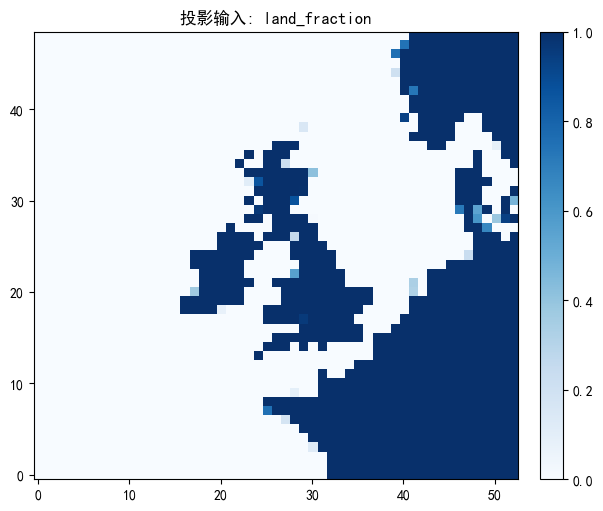

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(6.5, 5), constrained_layout=True)
im = ax.imshow(
    to_2d(land_frac),
    cmap="Blues",
    vmin=0,
    vmax=1,
    origin="lower",
    interpolation="nearest",
)
ax.set_title("投影输入: land_fraction")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()


#### 1.3 输出对比绘图



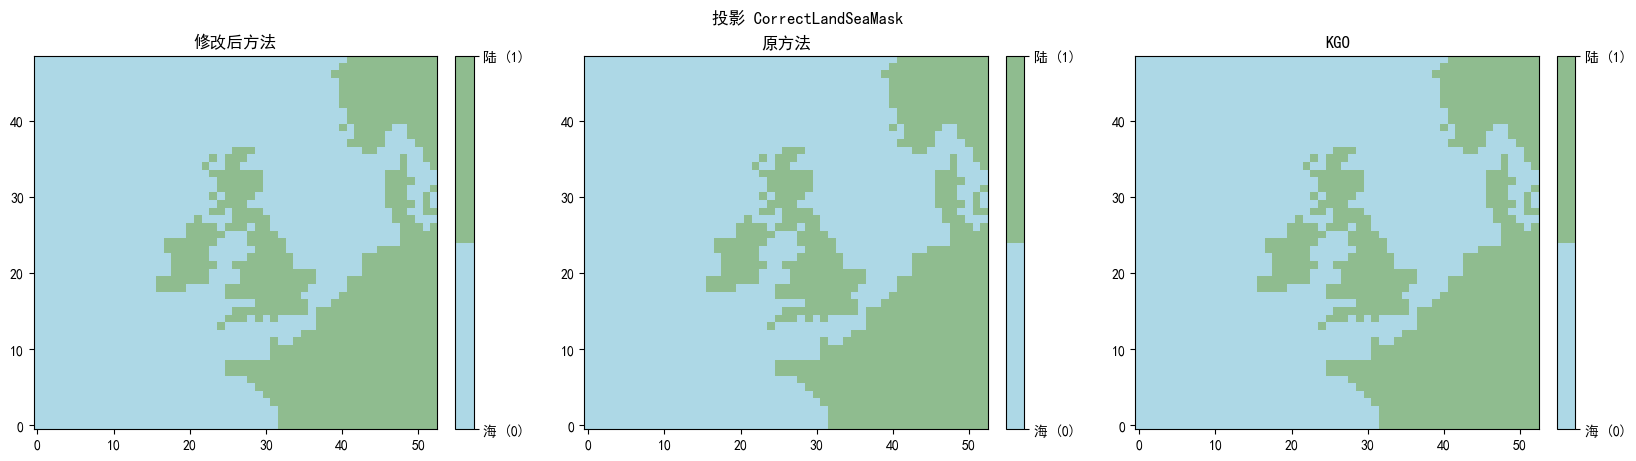

In [5]:
plot_landmask_pair_or_triplet(
    "投影 CorrectLandSeaMask",
    cur_2d,
    orig_2d,
    kgo=kgo_2d,
)


### 2. GenerateOrographyBandAncils

官方样例：`test_data/generate-topography-bands-mask`。

说明：`basic/input_land.nc` 已是二值 `land_binary_mask`，**不必**再经 `CorrectLandSeaMask`；
`CorrectLandSeaMask` 面向插值后的浮点 `land_fraction`（见上一节）。



#### 2.1 算法运行与数值对比

读取官方投影样例地形与海陆掩码，分别用修改后方法与原方法（Iris Cube 现场调用）生成地形带掩码，并与 KGO 数值对比。


In [6]:
orography_raw = load_primary_dataarray(BASIC_DIR / "input_orog.nc")
landmask_raw = load_primary_dataarray(BASIC_DIR / "input_land.nc")

orography = to_meb_gridda(orography_raw)
landmask = to_meb_gridda(landmask_raw)

json_thresholds = load_thresholds_from_json(BASIC_DIR / "bounds.json")

# 修改后方法（meb 六维）
plugin = GenerateOrographyBandAncils()
result_basic = plugin(orography, THRESHOLDS_DICT, landmask=landmask)
result_json = plugin(orography, json_thresholds, landmask=landmask)
result_no_landmask = plugin(orography, THRESHOLDS_DICT, landmask=None)

# 原方法
orog_cube = iris.load_cube(str(BASIC_DIR / "input_orog.nc"))
land_cube = iris.load_cube(str(BASIC_DIR / "input_land.nc"))
orig_plugin = OrigBandsPlugin()
original_basic = orig_plugin(
    orog_cube.copy(), THRESHOLDS_DICT, landmask=land_cube.copy()
).concatenate_cube()
original_json = orig_plugin(
    orog_cube.copy(), json_thresholds, landmask=land_cube.copy()
).concatenate_cube()
original_no_landmask = orig_plugin(
    orog_cube.copy(), THRESHOLDS_DICT, landmask=None
).concatenate_cube()

kgo_basic = load_primary_dataarray(BASIC_DIR / "kgo.nc")
kgo_json = load_primary_dataarray(BASIC_DIR / "kgo_from_json_bounds.nc")
kgo_no_landmask = load_primary_dataarray(NO_LANDMASK_DIR / "kgo.nc")

print("orography:", orography.name, orography.shape)
print("landmask:", landmask.name, landmask.shape)
print("bands(default):", result_basic.sizes.get("level"))

print("=== 默认阈值 + 海陆掩码 ===")
describe_bands(result_basic)
print("=== JSON 阈值 + 海陆掩码 ===")
describe_bands(result_json)
print("=== 默认阈值 + 无海陆掩码 ===")
describe_bands(result_no_landmask)

CLI_INPUT_DIR.mkdir(parents=True, exist_ok=True)
orography_cli_path = CLI_INPUT_DIR / "input_orog_meb.nc"
landmask_cli_path = CLI_INPUT_DIR / "input_land_meb.nc"
meb.write_griddata_to_nc(orography.astype(np.float32), str(orography_cli_path), creat_dir=True)
meb.write_griddata_to_nc(landmask.astype(np.float32), str(landmask_cli_path), creat_dir=True)
print("已写出 CLI 输入:", orography_cli_path)
print("已写出 CLI 输入:", landmask_cli_path)


orography: surface_altitude (1, 1, 1, 1, 100, 100)
landmask: land_binary_mask (1, 1, 1, 1, 100, 100)
bands(default): 12
=== 默认阈值 + 海陆掩码 ===
band_index | center | lower | upper
         0 | -225.0 | -500.0 |   50.0
         1 |   75.0 |   50.0 |  100.0
         2 |  125.0 |  100.0 |  150.0
         3 |  175.0 |  150.0 |  200.0
         4 |  225.0 |  200.0 |  250.0
         5 |  275.0 |  250.0 |  300.0
         6 |  350.0 |  300.0 |  400.0
         7 |  450.0 |  400.0 |  500.0
         8 |  575.0 |  500.0 |  650.0
         9 |  725.0 |  650.0 |  800.0
        10 |  875.0 |  800.0 |  950.0
        11 | 3475.0 |  950.0 | 6000.0
=== JSON 阈值 + 海陆掩码 ===
band_index | center | lower | upper
         0 | -250.0 | -500.0 |    0.0
         1 |   75.0 |    0.0 |  150.0
         2 |  175.0 |  150.0 |  200.0
         3 |  250.0 |  200.0 |  300.0
         4 |  450.0 |  300.0 |  600.0
=== 默认阈值 + 无海陆掩码 ===
band_index | center | lower | upper
         0 | -225.0 | -500.0 |   50.0
         1 |   75.0 |   

#### 2.2 输入数据绘图



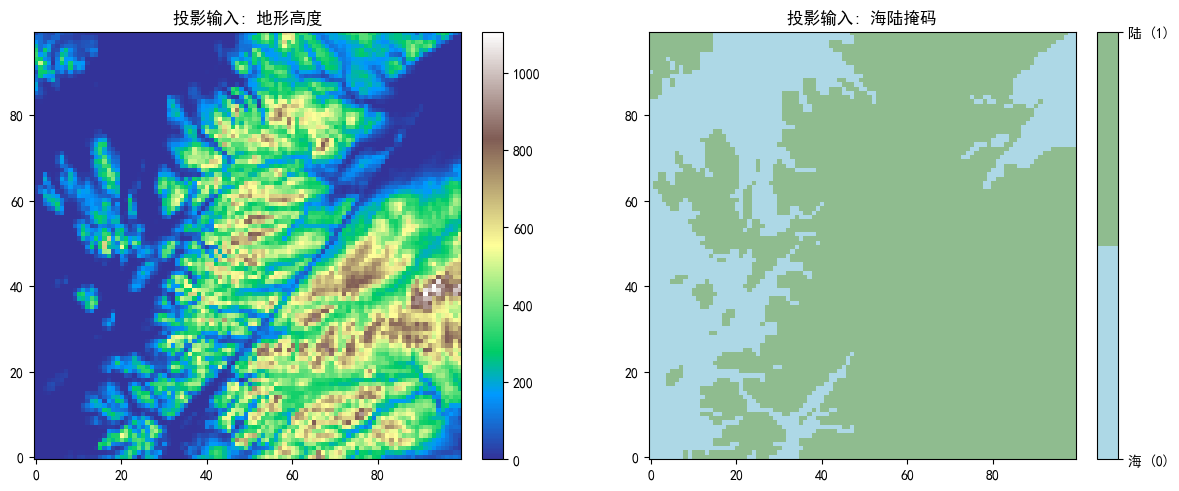

In [7]:
plot_auxiliary_data(
    "投影输入",
    orography.isel(member=0, level=0, time=0, dtime=0),
    landmask.isel(member=0, level=0, time=0, dtime=0),
)


#### 2.3 输出对比绘图



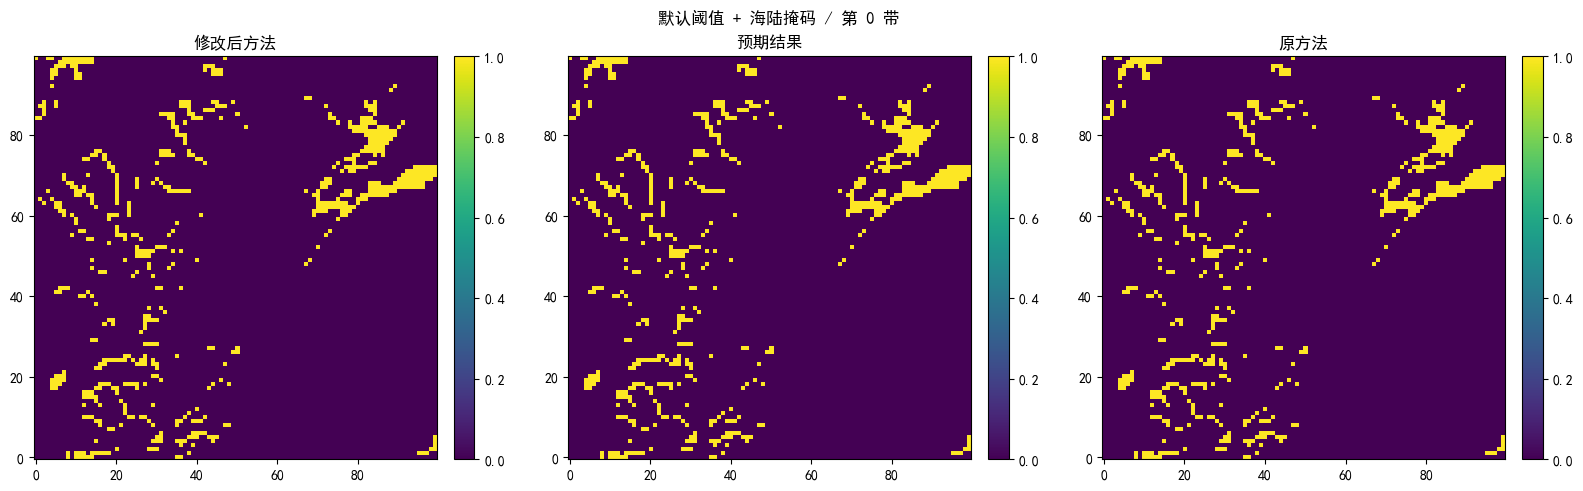

[默认阈值 + 海陆掩码] max_abs(修改后方法-KGO): 0.0
[默认阈值 + 海陆掩码] max_abs(修改后方法-原方法): 0.0


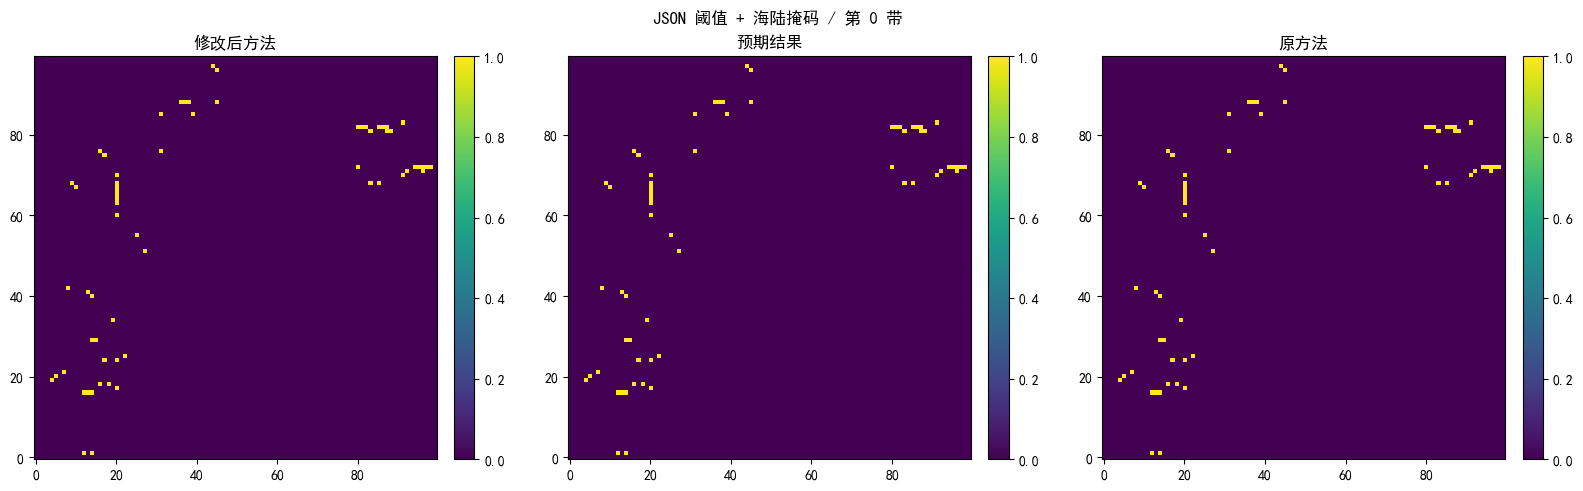

[JSON 阈值 + 海陆掩码] max_abs(修改后方法-KGO): 0.0
[JSON 阈值 + 海陆掩码] max_abs(修改后方法-原方法): 0.0


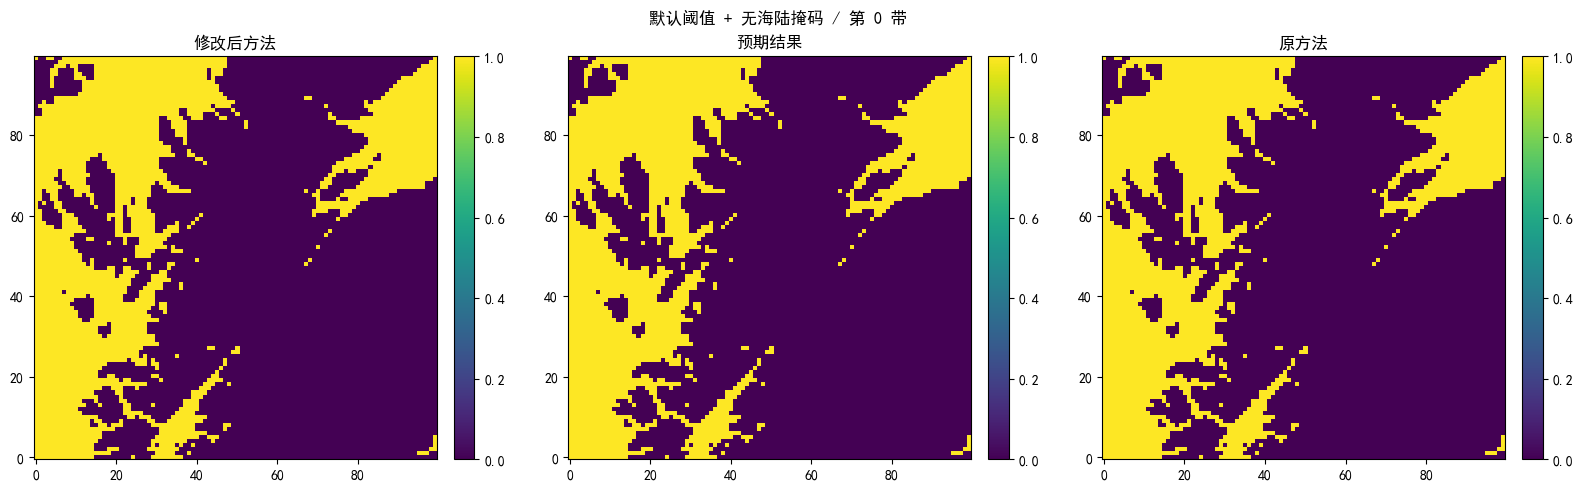

[默认阈值 + 无海陆掩码] max_abs(修改后方法-KGO): 0.0
[默认阈值 + 无海陆掩码] max_abs(修改后方法-原方法): 0.0


In [8]:
# 三种场景取第 0 带做对比图
cases = [
    ("默认阈值 + 海陆掩码", result_basic, kgo_basic, original_basic),
    ("JSON 阈值 + 海陆掩码", result_json, kgo_json, original_json),
    ("默认阈值 + 无海陆掩码", result_no_landmask, kgo_no_landmask, original_no_landmask),
]
for title, result, kgo, original in cases:
    modified_2d = result.isel(level=0).squeeze().values
    kgo_2d_band = kgo.isel(topographic_zone=0).squeeze().values
    # original_* 为 Iris Cube（concatenate_cube 结果），第 0 维即 topographic_zone
    original_2d_band = np.asarray(original.data[0], dtype=np.float64)
    plot_result_triplet(
        f"{title} / 第 0 带",
        modified_2d,
        kgo_2d_band,
        original_2d_band,
    )
    print(
        f"[{title}] max_abs(修改后方法-KGO):",
        float(np.max(np.abs(modified_2d - kgo_2d_band))),
    )
    print(
        f"[{title}] max_abs(修改后方法-原方法):",
        float(np.max(np.abs(modified_2d - original_2d_band))),
    )


## 经纬坐标输入

本模块算法**不读取**坐标数值做距离/梯度计算，仅用维度对齐。因此经纬分支可将**输入与投影 KGO**重网格到同一规则经纬网格后再对比。

说明：与 `generate_orographic_smoothing_coefficients` 不同——后者结果依赖格距，重网格后的投影 KGO 不能代表「经纬输入上重算」的参考；本模块分带/二值化是格点逐点运算，重网格 KGO 可作为参考。残余差异主要来自「先插值再阈值」与「先阈值再插值」的顺序不同，通常仅出现在边界附近。



### 1. CorrectLandSeaMask



#### 1.1 算法运行与数值对比



In [9]:
land_cube = iris.load_cube(str(LANDMASK_BASIC / "input.nc"))
kgo_land_cube = iris.load_cube(str(LANDMASK_BASIC / "kgo.nc"))
target = build_regular_latlon_target(land_cube, resolution=0.05)
land_latlon_cube = regrid_to_target(land_cube, target, scheme="linear")
# 二值 KGO 用 nearest，避免线性插值产生中间值
kgo_land_ll_cube = regrid_to_target(kgo_land_cube, target, scheme="nearest")

# 业务经纬约定：坐标不写 units；场单位继承原 Cube
land_frac_ll = make_meb6d_latlon(
    cube_data_to_float32(land_latlon_cube),
    lat=land_latlon_cube.coord("latitude").points,
    lon=land_latlon_cube.coord("longitude").points,
    name="land_fraction",
    units=str(land_latlon_cube.units),
)
print("latlon input:", land_frac_ll.shape, "lat attrs=", dict(land_frac_ll.coords["lat"].attrs))
assert "units" not in land_frac_ll.coords["lat"].attrs

cur_ll = CorrectLandSeaMask().process(land_frac_ll)
orig_ll_cube = OrigCorrectLandSeaMask()(land_latlon_cube)
orig_ll = make_meb6d_latlon(
    np.asarray(orig_ll_cube.data, dtype=np.float32),
    lat=land_latlon_cube.coord("latitude").points,
    lon=land_latlon_cube.coord("longitude").points,
    name="land_binary_mask",
    units=str(orig_ll_cube.units),
)

cur_ll_2d = to_2d(cur_ll)
orig_ll_2d = to_2d(orig_ll)
kgo_ll_2d = np.asarray(kgo_land_ll_cube.data, dtype=np.float64)
print("max_abs(修改后方法-原方法) latlon:", float(np.nanmax(np.abs(cur_ll_2d - orig_ll_2d))))
print("max_abs(修改后方法-重网格KGO) latlon:", float(np.nanmax(np.abs(cur_ll_2d - kgo_ll_2d))))
print(
    "disagree_frac(修改后方法 vs 重网格KGO):",
    float(np.mean(cur_ll_2d != kgo_ll_2d)),
)
np.testing.assert_array_equal(cur_ll_2d, orig_ll_2d)
print("CorrectLandSeaMask 经纬路径：与原方法一致；与重网格 KGO 的差异主要在边界。")


latlon input: (1, 1, 1, 1, 346, 792) lat attrs= {}
max_abs(修改后方法-原方法) latlon: 0.0
max_abs(修改后方法-重网格KGO) latlon: 1.0
disagree_frac(修改后方法 vs 重网格KGO): 0.009564576399836516
CorrectLandSeaMask 经纬路径：与原方法一致；与重网格 KGO 的差异主要在边界。


#### 1.2 输出对比绘图


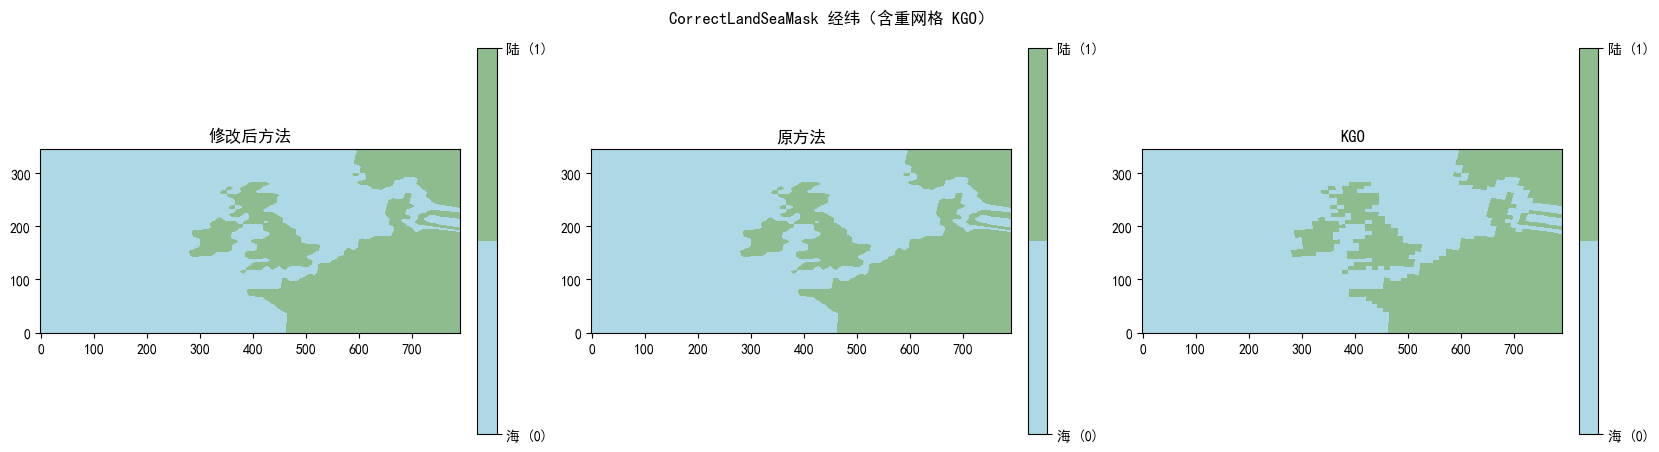

In [10]:
plot_landmask_pair_or_triplet(
    "CorrectLandSeaMask 经纬（含重网格 KGO）",
    cur_ll_2d,
    orig_ll_2d,
    kgo=kgo_ll_2d,
)


### 2. GenerateOrographyBandAncils

将投影官方输入与 KGO 重网格到同一经纬网格：主判据仍是同一经纬输入下的「修改后方法 vs 原方法」；重网格 KGO 作参考三联图。



#### 2.1 算法运行与数值对比



In [11]:
orog_cube = iris.load_cube(str(BASIC_DIR / "input_orog.nc"))
land_bin_cube = iris.load_cube(str(BASIC_DIR / "input_land.nc"))
kgo_bands_cube = iris.load_cube(str(BASIC_DIR / "kgo.nc"))
bands_target = build_regular_latlon_target(orog_cube, resolution=0.05)
orog_ll_cube = regrid_to_target(orog_cube, bands_target, scheme="linear")
land_ll_cube = regrid_to_target(land_bin_cube, bands_target, scheme="nearest")
# 投影 KGO 第 0 带 → 同一目标网格（二值场用 nearest）
kgo_band0_ll_cube = regrid_to_target(kgo_bands_cube[0], bands_target, scheme="nearest")

orog_ll = make_meb6d_latlon(
    cube_data_to_float32(orog_ll_cube),
    lat=orog_ll_cube.coord("latitude").points,
    lon=orog_ll_cube.coord("longitude").points,
    name="orography",
    units=str(orog_ll_cube.units),
)
land_ll = make_meb6d_latlon(
    cube_data_to_float32(land_ll_cube),
    lat=land_ll_cube.coord("latitude").points,
    lon=land_ll_cube.coord("longitude").points,
    name="land_binary_mask",
    units=str(land_ll_cube.units),
)
# 修改后方法
cur_bands_ll = GenerateOrographyBandAncils().process(
    orog_ll, THRESHOLDS_DICT, landmask=land_ll
)
# 原方法
orig_bands_ll = OrigBandsPlugin()(
    orog_ll_cube, THRESHOLDS_DICT, landmask=land_ll_cube
)

cur0 = to_2d(cur_bands_ll.isel(level=0)).astype(float)
# 原插件返回 CubeList，每个元素对应一个地形带
orig0 = to_2d(np.asarray(orig_bands_ll[0].data)).astype(float)
kgo0_ll = to_2d(np.asarray(kgo_band0_ll_cube.data)).astype(float)

print("bands latlon shapes:", cur0.shape, orig0.shape, kgo0_ll.shape)
print("max_abs(修改后方法-原方法) band0:", float(np.nanmax(np.abs(cur0 - orig0))))
print("max_abs(修改后方法-重网格KGO) band0:", float(np.nanmax(np.abs(cur0 - kgo0_ll))))
print("disagree_frac(修改后方法 vs 重网格KGO) band0:", float(np.mean(cur0 != kgo0_ll)))
np.testing.assert_array_equal(cur0, orig0)
print("GenerateOrographyBandAncils 经纬路径：与原方法一致；与重网格 KGO 的差异主要在边界。")


bands latlon shapes: (38, 69) (38, 69) (38, 69)
max_abs(修改后方法-原方法) band0: 0.0
max_abs(修改后方法-重网格KGO) band0: 1.0
disagree_frac(修改后方法 vs 重网格KGO) band0: 0.02212051868802441
GenerateOrographyBandAncils 经纬路径：与原方法一致；与重网格 KGO 的差异主要在边界。


#### 2.2 输出对比绘图


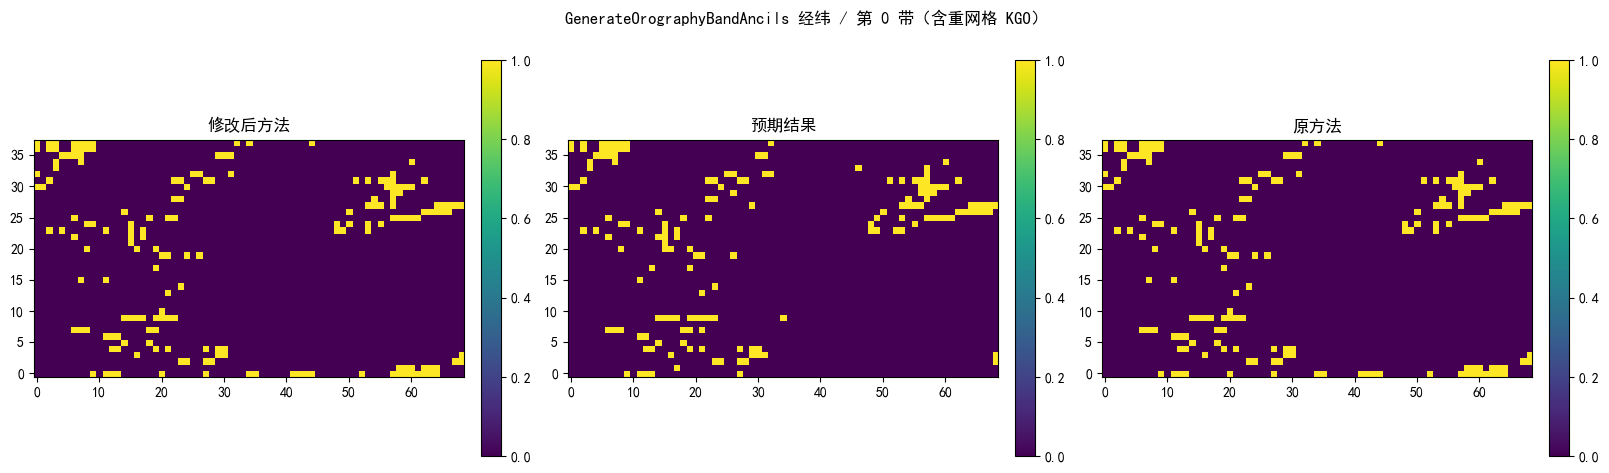

In [12]:
plot_result_triplet(
    "GenerateOrographyBandAncils 经纬 / 第 0 带（含重网格 KGO）",
    cur0,
    kgo0_ll,
    orig0,
)


## CLI应用示例与结果对比

修改后 CLI 现场调用；原方法 CLI 结果读取 Improver 命令写出的 `original_cli_*.nc`（由仓库根目录 `_gen_original_cli.py` 生成）。


### 1. CorrectLandSeaMask

读取投影章写出的 meb 输入，对比：修改后 CLI | 原方法 CLI | KGO。


CLI wrote: D:\workspace\improver\generate_ancillary\test_data\generate-landmask\basic\cli_outputs\cli_landmask_result.nc shape= (1, 1, 1, 1, 49, 53)
max_abs(修改后CLI-KGO): 0.0
max_abs(修改后CLI-原方法CLI): 0.0
max_abs(原方法CLI-KGO): 0.0
CorrectLandSeaMask：修改后 CLI / 原方法 CLI 均与 KGO 一致。


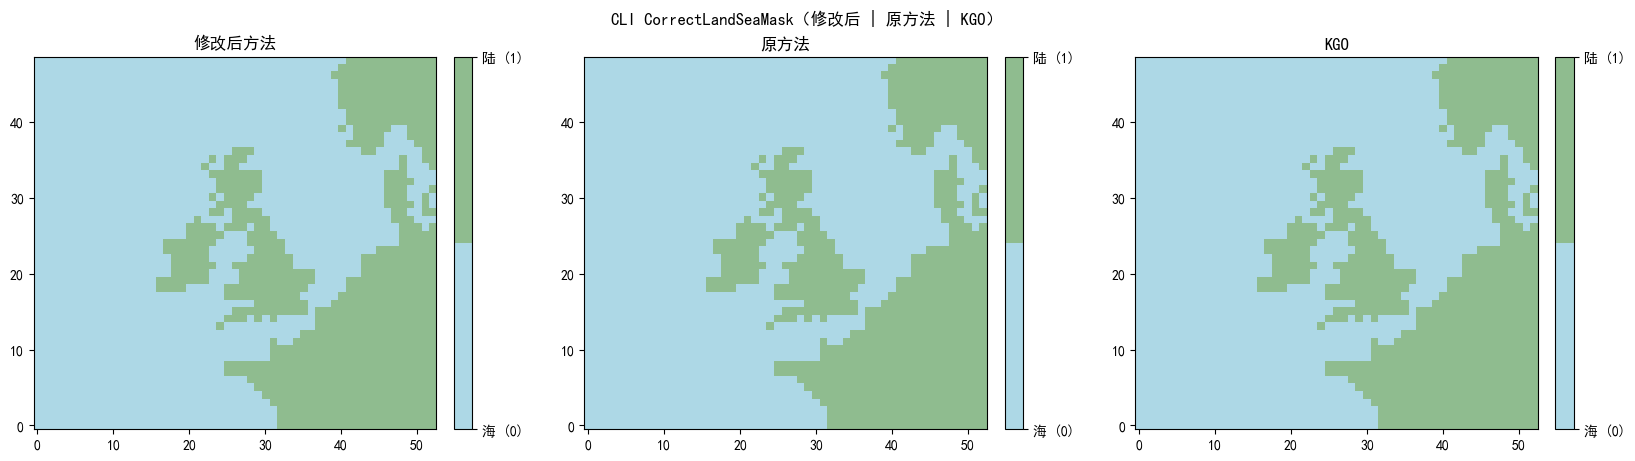

In [13]:
from generate_ancillary.cli.anc_generate_landmask_ancillary import process as landmask_cli_process

LM_CLI_OUTPUT.mkdir(parents=True, exist_ok=True)
lm_out = LM_CLI_OUTPUT / "cli_landmask_result.nc"

# 修改后方法CLI
cli_lm = landmask_cli_process(
    landmask_path=str(LM_CLI_INPUT / "input_landmask_meb.nc"),
    output_path=str(lm_out),
)
cli_2d = to_2d(cli_lm).astype(np.float64)

# 原方法 CLI：Improver generate-landmask-ancillary 写出
orig_cli_lm = load_primary_dataarray(LM_CLI_OUTPUT / "original_cli_landmask_result.nc")
orig_cli_2d = to_2d(orig_cli_lm).astype(np.float64)

print("CLI wrote:", lm_out, "shape=", cli_lm.shape)
print("max_abs(修改后CLI-KGO):", float(np.max(np.abs(cli_2d - kgo_2d))))
print("max_abs(修改后CLI-原方法CLI):", float(np.max(np.abs(cli_2d - orig_cli_2d))))
print("max_abs(原方法CLI-KGO):", float(np.max(np.abs(orig_cli_2d - kgo_2d))))
np.testing.assert_array_equal(cli_2d, kgo_2d)
np.testing.assert_array_equal(orig_cli_2d, kgo_2d)
print("CorrectLandSeaMask：修改后 CLI / 原方法 CLI 均与 KGO 一致。")

plot_landmask_pair_or_triplet(
    "CLI CorrectLandSeaMask（修改后 | 原方法 | KGO）",
    cli_2d,
    orig_cli_2d,
    kgo=kgo_2d,
)


### 2. GenerateOrographyBandAncils

调用 `dsc_generate_topography_bands_mask.process`（JSON 阈值场景），对比修改后 CLI / 原方法 CLI / KGO。


shape(cli): (5, 100, 100) shape(orig_cli): (5, 100, 100) shape(kgo): (5, 100, 100)
max_abs(修改后CLI-KGO): 0.0
max_abs(修改后CLI-原方法CLI): 0.0
max_abs(原方法CLI-KGO): 0.0


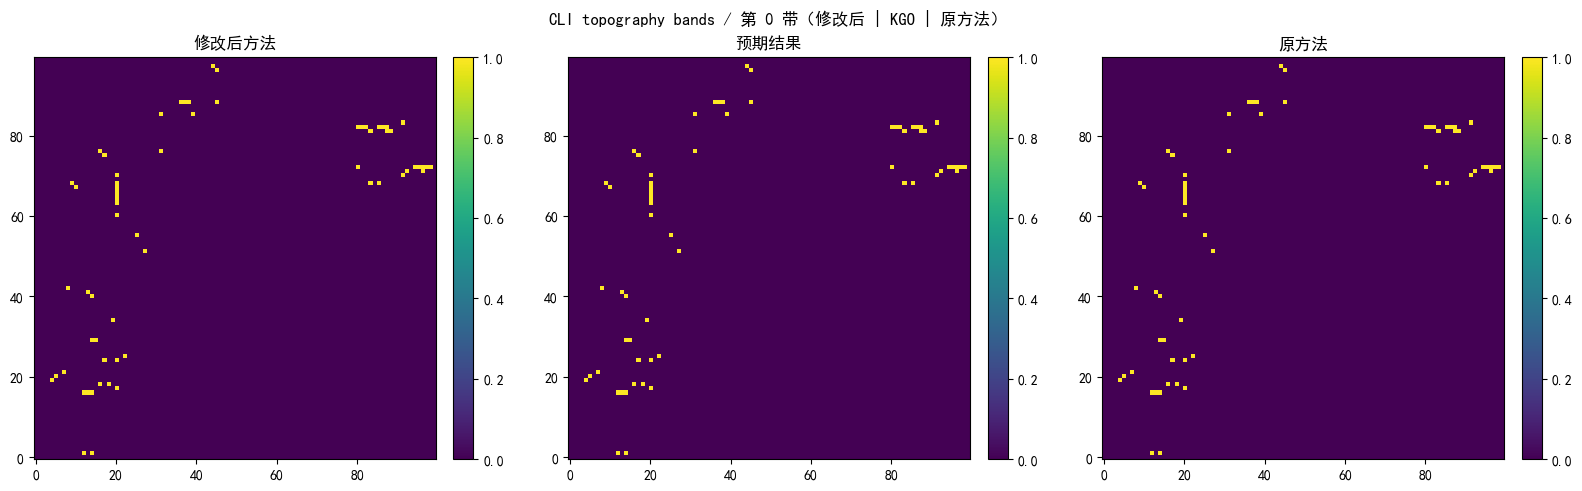

In [14]:
from generate_ancillary.cli.dsc_generate_topography_bands_mask import process as bands_cli_process

CLI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
cli_result_path = CLI_OUTPUT_DIR / "cli_topography_bands_mask_result.nc"

# 修改后方法CLI
bands_cli_process(
    orography_path=str(CLI_INPUT_DIR / "input_orog_meb.nc"),
    landmask_path=str(CLI_INPUT_DIR / "input_land_meb.nc"),
    thresholds_path=str(BASIC_DIR / "bounds.json"),
    output_path=str(cli_result_path),
)

cli_result = meb.read_griddata_from_nc(str(cli_result_path))
cli_cube = np.asarray(cli_result.squeeze(drop=True).values)
kgo_cube = np.asarray(kgo_json.squeeze(drop=True).values)

# 原方法 CLI：Improver generate-topography-bands-mask 写出
orig_cli_bands = load_primary_dataarray(
    CLI_OUTPUT_DIR / "original_cli_topography_bands_mask_result.nc"
)
orig_cli_cube = np.asarray(orig_cli_bands.squeeze(drop=True).values)

print("shape(cli):", cli_cube.shape, "shape(orig_cli):", orig_cli_cube.shape, "shape(kgo):", kgo_cube.shape)
print("max_abs(修改后CLI-KGO):", float(np.max(np.abs(cli_cube - kgo_cube))))
print("max_abs(修改后CLI-原方法CLI):", float(np.max(np.abs(cli_cube - orig_cli_cube))))
print("max_abs(原方法CLI-KGO):", float(np.max(np.abs(orig_cli_cube - kgo_cube))))

plot_result_triplet(
    "CLI topography bands / 第 0 带（修改后 | KGO | 原方法）",
    cli_cube[0],
    kgo_cube[0],
    orig_cli_cube[0],
)
